# **Aprendizaje Automático II: Apredizaje no supervisado**

## **Carga de librerias**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

## **Tarea 2.1: Preprocesado**
Ya tenemos el CSV del dataset preprocesado, ahora lo cargaremos para trabajar con él.

In [6]:
df = pd.read_csv('../data/dataset_preprocesado.csv', index_col=0)
X = df.values
df.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo
0,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460
1,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203
2,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909
3,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155
4,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989


## **Tarea 2.2: Búsqueda del número de clústers adecuado**
## **Tarea 2.3: ¿Cómo varía la calidad del clustering con diferentes valores de 'K'?**

RESPONDEREMOS A AMBAS PREGUNTAS A LA VEZ


Para determinar el número óptimo de clústers (K) en el conjunto de datos hemos realizado un análisis multicriterio utilizando métricas de validación interrna (sin etiquetas previas), o sea, se basan únicamente en la estructura intrínseca de los datos.  
Utilizando el modelo particional K-means probaremos con un rango de número de clústers para ver cuál se adecúa más a nuestro dataset.  
Después visualizaremos los resultados de los diferentes métodos de selección de número de clústers mediante varias gráficas: 
- Inercia (método del codo)
- Coeficiente de Silueta
- Índice Calinski-Harabasz
- Índice Davies-Bouldin 

Al usar diferentes métricas aseguramos una mayor robustez.

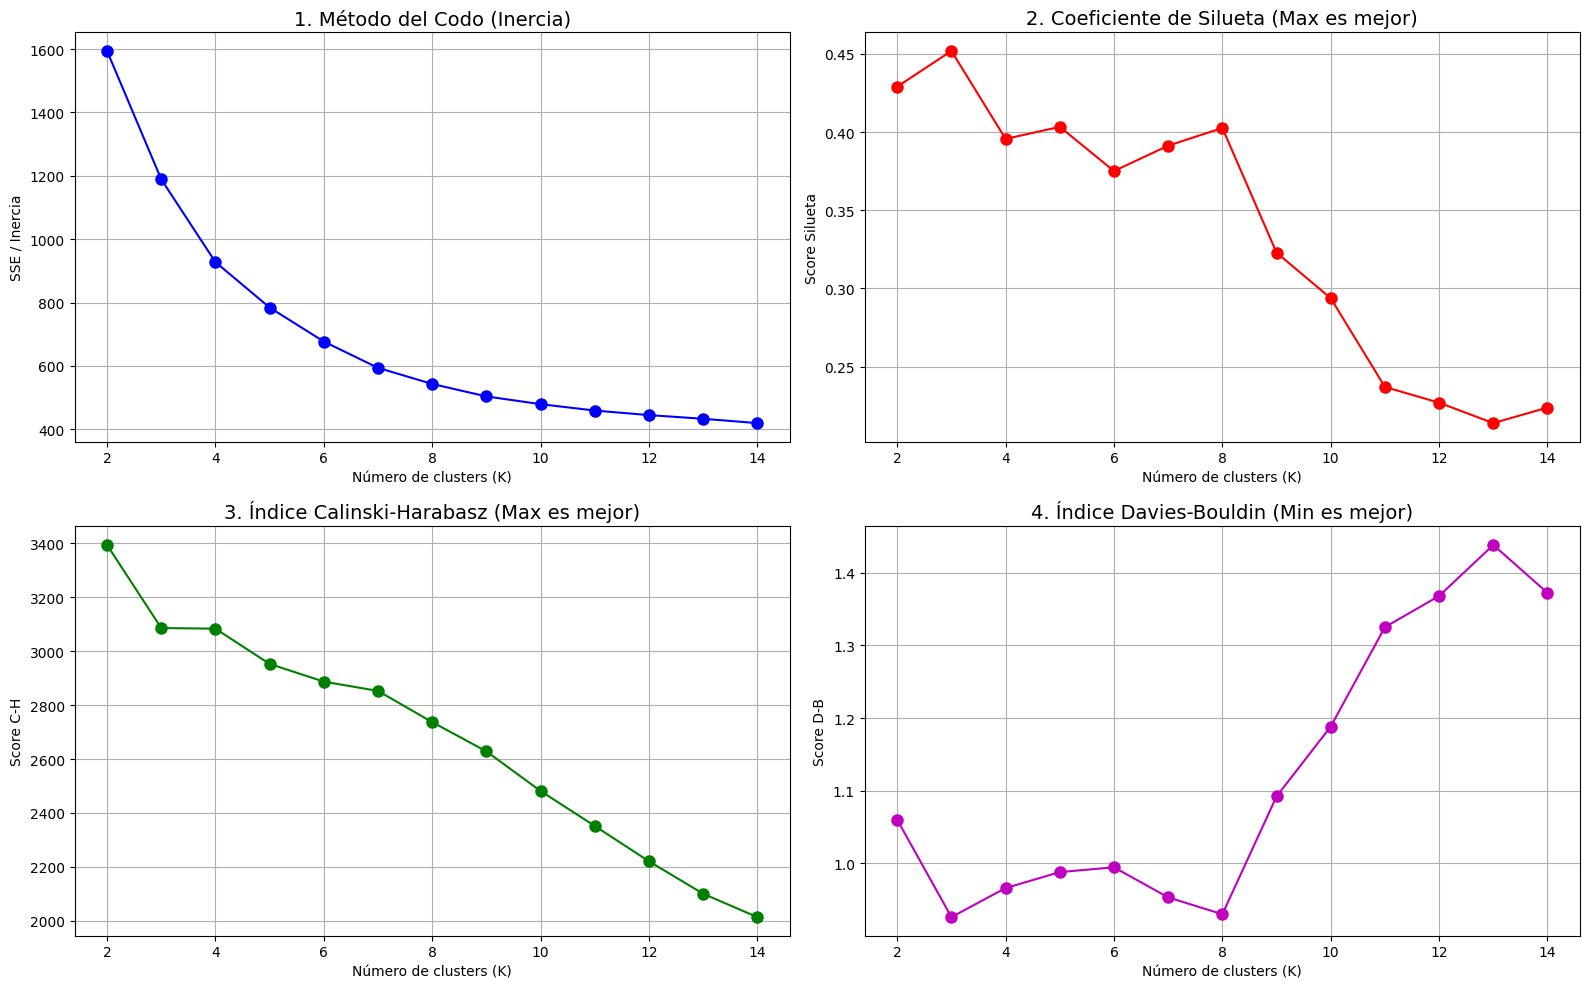


--- RESUMEN DE MÉTRICAS DE EVALUACIÓN ---


,K,Inercia (Codo),Silueta,Calinski-Harabasz,Davies-Bouldin
0,2,1594.3101,0.4291,3394.1508,1.0601
1,3,1189.1548,0.4519,3086.0334,0.9260
2,4,927.7605,0.3956,3083.5949,0.9660
3,5,784.2884,0.4034,2952.8754,0.9880
4,6,676.9386,0.3751,2887.2829,0.9946
5,7,593.9093,0.3913,2852.7266,0.9532
6,8,543.0674,0.4026,2737.1728,0.9300
7,9,503.6302,0.3229,2628.5843,1.0922
8,10,479.2636,0.2937,2481.6544,1.1884
9,11,459.0910,0.2370,2352.0252,1.3252


In [7]:
range_k = range(2, 15)  # Probamos hasta 14 clústers

# Listas para almacenar métricas
inercias = []
siluetas = []
calinski = []
davies_bouldin = []

# Cálculo de métricas para cada K
for k in range_k:
    # Hacemos resultados reproducibles
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X, labels))
    calinski.append(calinski_harabasz_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))




# VISUALIZACIÓN DE LOS RESULTADOS
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Método del Codo (Inercia)
axs[0, 0].plot(range_k, inercias, 'bo-', markersize=8)
axs[0, 0].set_title('1. Método del Codo (Inercia)', fontsize=14)
axs[0, 0].set_xlabel('Número de clusters (K)')
axs[0, 0].set_ylabel('SSE / Inercia')
axs[0, 0].grid(True)

# Coeficiente de Silueta
axs[0, 1].plot(range_k, siluetas, 'ro-', markersize=8)
axs[0, 1].set_title('2. Coeficiente de Silueta (Max es mejor)', fontsize=14)
axs[0, 1].set_xlabel('Número de clusters (K)')
axs[0, 1].set_ylabel('Score Silueta')
axs[0, 1].grid(True)

# Índice Calinski-Harabasz
axs[1, 0].plot(range_k, calinski, 'go-', markersize=8)
axs[1, 0].set_title('3. Índice Calinski-Harabasz (Max es mejor)', fontsize=14)
axs[1, 0].set_xlabel('Número de clusters (K)')
axs[1, 0].set_ylabel('Score C-H')
axs[1, 0].grid(True)

# Índice Davies-Bouldin
axs[1, 1].plot(range_k, davies_bouldin, 'mo-', markersize=8)
axs[1, 1].set_title('4. Índice Davies-Bouldin (Min es mejor)', fontsize=14)
axs[1, 1].set_xlabel('Número de clusters (K)')
axs[1, 1].set_ylabel('Score D-B')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Tabla de resumen comparativo
df_metricas = pd.DataFrame({
    'K': range_k,
    'Inercia (Codo)': inercias,
    'Silueta': siluetas,
    'Calinski-Harabasz': calinski,
    'Davies-Bouldin': davies_bouldin
})
print("\n--- RESUMEN DE MÉTRICAS DE EVALUACIÓN ---")
display(df_metricas.round(4))

#### Análisis de los resultados:

La calidad del clústering lo medimos en un valor que evoluciona siguiendo una relación de compromiso entre simplificación de los datos y la precisión del ajuste.  
Según los resultados obtenidos con las métricas aplicadas, destacamos lo siguiente de cara a elegir el número de clústers ideal:

- Gráfico de inercia: La inercia mide la cohesión de los clústers (suma de las distancias al cuadrado de cada punto a su centroide). A medida que aumenta el valor de 'K', la intercia siempre disminuye, lo cual se debe a qeu, al tener más centroides, los puntos están inevitablemente más cerca de su centro asignado. En la gráfica generada, se observa un descenso pronunciado desde k=2 hasta k=3, la curva experimenta una disminución de la pendiente, formando e lcodo. Esto indica que aumentar el número de grupos más allá de 3 no reduce significativamente la varianza interna, lo que sugiere que 3 clúsetrs es un equilibrio óptimo entre complejidad y error.

- Gráfico de silueta: El Coeficiente de Silueta combina la cohesión (proximidad a su propio clúster) y la separación (lejanía del clúster vecino más cercano), por lo cual, un mayor valor es mejor. No es monótono, suele subir hasta un punto óptimo y luego decrece. El valor máximo se alcanza en k=3 con un valor de 0.45 (valores más cercanos a 1 indican una estructura de clústering fuerte), por lo cual este método nos apunta a que k=3 es la configuración donde los puntos están mejor asignados a sus clústers. De k=2 a k=3 la calidad sube porque estamos separando grupos que realmente eran distintos, pero, a medida que aumentamos la 'k' la silueta tiende a bajar porque estamos forzando divisiones de grupos que ya eran densos, lo que acerca las fronteras entre clústers. 

- Gráfico de Calinski-Harabasz: Evalúa la relación entre la dispersión entre clústers y la dispersión interna, por lo cual, valores más altos indican clústers mejor definidos. Nuestros resultados indican el pico más alto en k=2, el cual baja en k=3, pero a partir de ahí la bajada es muchísimo más suave. Esto nos indicaría que deberíamos escoger k=2, aún así viendo la tendencia de las dos gráficas anteriores, k=3 no es una mala opción.

- Gráfico de Davies-Bouldin: Indica cuánto de similares son los clústers entre sí, por lo que un valor menor es mejor. En nuestra gráfica, el valor mínimo se encuentra en k=3.


Se observa que el modelo alcanza un óptimo corroborado por las 4 métricas en k=3. Sin embargo considerando el enunciado del dataset, el cual establece la existencia de al menos 6 géneros musicales, haremos un cambio de selección asentando como mínimo k=6.

Al tener establecido un mínimo de 6 géneros, pasamos de buscar solamente calidad a también buscar resolución.  
Con k=3 la calidad es óptima matemáticamente pero de manera informativa es pobre (solo tendríamos 3 géneros para miles de canciones).

Para esto, observando de nuevo los gráficos contando a partir de k=6, podemos observar en el Coeficiente de Silueta que k=8 muestra el pico más grande (el mejor), coincidiendo con el pico mínimo de Davies-Bouldin, también en k=8, y las demás gráficas no presentan ninguna objeción frente a este número, por lo cual será nuestra elección para el modelo final.

In [8]:
# Entrenamiento del modelo final
modelo_final = KMeans(n_clusters=8, n_init=10, random_state=42)
df['cluster'] = modelo_final.fit_predict(X)

# Ver cuántas canciones han caído en cada género
print(df['cluster'].value_counts())

cluster
2    1575
1    1051
4     885
5     442
0     269
3     228
7     189
6     126
Name: count, dtype: int64


## **Tarea 2.4: Con el número más adecuado de clusters, ayúdate de estadísticas para analizar las canciones incluidas en cada cluster**

Vamos a caracterizar cada uno de los 8 grupos basándonos en sus estadísticas descriptivas.

Primero calculamos la media de cada atributo por clúster y generaremos un mapa de calor para comparar clusters.

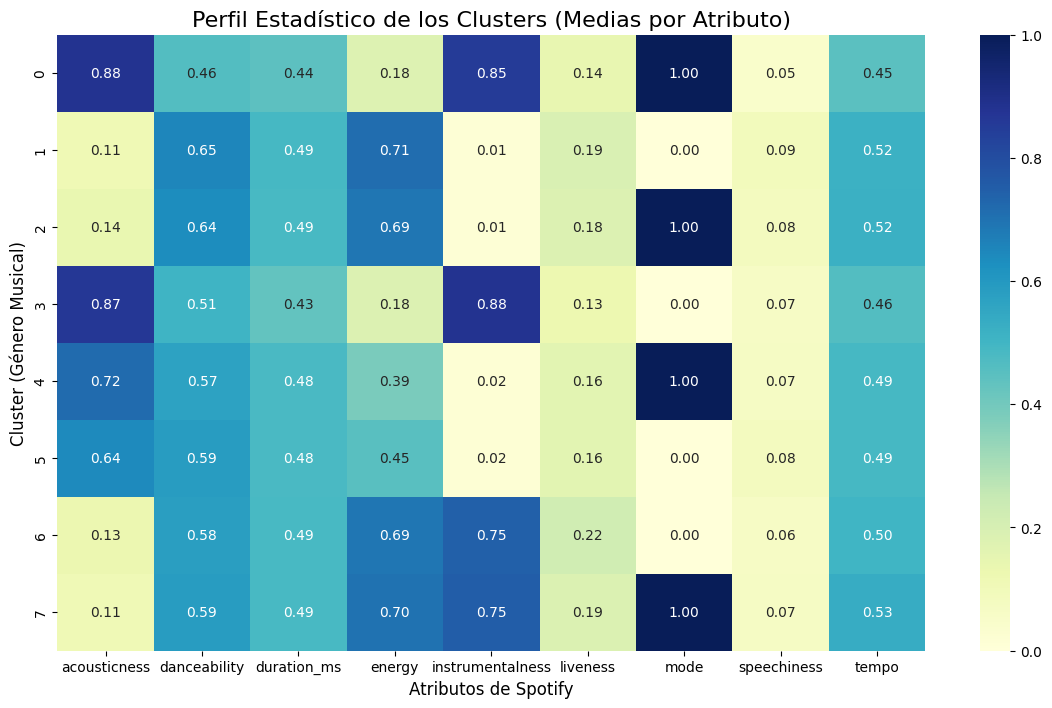

Tabla de Medias por Cluster:


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo
cluster,,,,,,,,,
0,0.881115,0.464632,0.444455,0.177210,0.854784,0.141292,1.0,0.046751,0.446004
1,0.114592,0.648640,0.490564,0.713665,0.014840,0.191888,0.0,0.091452,0.517874
2,0.139166,0.636007,0.487421,0.689889,0.014688,0.179944,1.0,0.083462,0.521541
3,0.865101,0.507364,0.430262,0.180249,0.879461,0.128530,0.0,0.065928,0.464388
4,0.715508,0.568376,0.482113,0.386059,0.018179,0.162746,1.0,0.068309,0.491592
5,0.644204,0.586321,0.483390,0.449300,0.019345,0.164002,0.0,0.083544,0.491121
6,0.130452,0.579889,0.488106,0.690897,0.745794,0.220627,0.0,0.064375,0.503648
7,0.111351,0.589595,0.486031,0.700967,0.752783,0.186251,1.0,0.069999,0.534858


In [9]:
# Cálculo de estadísticas descriptivas (media por cluster)
stats_clusters = df.groupby('cluster').mean()

# Visualización mediante mapa de alor (Heatmap)
plt.figure(figsize=(14, 8))
sns.heatmap(stats_clusters, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Perfil Estadístico de los Clusters (Medias por Atributo)', fontsize=16)
plt.xlabel('Atributos de Spotify', fontsize=12)
plt.ylabel('Cluster (Género Musical)', fontsize=12)
plt.show()

# Tabla de estadísticas
print("Tabla de Medias por Cluster:")
display(stats_clusters)

Pasamos a designar los géneros de cada uno de estos clústers según la información reocpilada:

- 0 -> CLASSICAL. Acústica altísima, instrumentalidad alta y energía muy baja.
- 1 -> HIP-HOP / RAP. tiene la speechiness (cantidad de lyrics) más alta. además tiene mucha energía y es bailable, además está en tonalidad menor, lo que encaja con un estilo más duro o urbano del rap.
- 2 -> POP. Es muy parecido al anterior (HIP-HOP/RAP), pero es más bailable y está en tonalidad mayor.
- 4 -> ACOUSTIC / FOLK. Acústica alta pero cero instrumentalidad siendo alegre.
- 5 -> ROCK. Es acústico y vocal, pero tiuene una energía media y tono menor, encaja bien con la definición de rock alternativo o indie.
- 6 -> ELECTRONIC / EDM. Energía alta, instrumentalidad alta

Faltan el 3 y el 7, de los cuales el enunciado no da pistas sobre ellos, pero intuimos lo siguiente:

- 3 -> SOUNDTRACK. Casi idéntico al clúster 0 (CLASSICAL) pero en tonalidad menor, coincidiendo con música ambiental, bandas sonoras, ...
- 7 -> DANCE-POP. Casi idéntido al clúster 6 pero en tonalidad mayor, la electrónica  suele ser menos oscura que el techno y más comercial.

## **Tarea 2.5: Compara los resultados obtenidos con K-means y el clustering aglomerativo/jerárquico. Discute las ventajas y desventajas de cada método en diferentes tipos de datos**

Ambos métodos nos indican que 8 clústers es lo mejor.

En silueta a ambois nos da más o menos 0.4 (a mi 0.4 a jerárquico 0.38)
En kalinski a mi 2700 a manu 2083, a pesar de que se diferencia, la magnitud es parecida, a mi kalinski me afirma merjor que 8 sea lo indicado

Para ambos algoritmos hemos recibido respuestas parecidas, ya que ambos nos indican que k=8 clústers es lo más apropiado, y esto es contrastado por las métricas en ambos modelos, por ejemplo:

- El coeficiente de Silueta da 0.38 pra jerárquico y 0.40 para particional.
- El índice de Calinski-Harabarsz es 2080 en jerárquico y 2700 en particional, a pesaar de la diferencia, la magnitud no difiere mucho.
- El índice de Davies-Bouldin es 0.97 en jerárquico y 0.93 en particional, igualmente parecido.

Esto significan que ambos algoritmos coinciden en la clasificación de los datos en 8 clústers, validando en general los 8 géneros identificados, que ahora, gracias a la comparación de diferentes algoritmos, no son fruto del azar de un algoritmo solo.

Diferenciando entre ambos algoritmos:

K-MEANS (particional):

- VENTAJAS: Eficiencia computacional; es mucho más rápido y consume menos memoria, lo cual es vital si trabajamos con datasets gigantescos. Además, es fácil de interpretar, simplemente cada dato pertenece a su centroide más cercano.

- DESVENTAJAS: Asume que los grupos son globulares, si un género musical tuviera una distribución alargada en sus atributos, K-means fallaría. Ademas, es sensible, ya que este depende de la inicialización de los centroides, los cuales son estocásticos, pero esto lo mitigamos con el parámetro 'n_init'.


CLÚSTERING AGLOMERATIVO (jerárquico):

- VENTAJAS: Permite generar un dendograma que da a ver la jerarquía (en nuestro caso podemos ver como POP y ROCK se fusionan justo antes dde unirse a CLASSICAL). Además tiene flexibilidad, puede detectar formas que no sean esféricas.

- DESVENTAJAS: Es mucho más lento (O(n^2)), con datasets muy grandes puede llegar a colapsar. Además, una vez que dos dats se unen en un paso de la jerarquía, no pueden separarse en pasos posteriores, lo que puede arrastrasr errores de los niveles más bajos.